In [1]:
# data tools and plotting

from feature_eng import TSFE
import logging
import warnings
from function import get_best_threshold
warnings.filterwarnings("ignore", category=FutureWarning)

logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)
#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay

import mlflow
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000);
#=========================
#=====================
#=========mlflow setting==========


#mlflow.set_tracking_uri(
#    "http://127.0.0.1:5000"
#)


#mlflow.set_experiment('isCnan_mhd')
#=============== feature engineering and define the needed features

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       'last_std_CH4_ht', 'last_air_CH4_ht', 'last_std_CH4_area',
       'last_air_CH4_area', 'last_std_CH4_rt', 'last_air_CH4_rt',
       'last_std_CH4_start_level', 'last_air_CH4_start_level',
       'level_rt_ratio', 'rt_position', 'baseline_slope', 'level_area_ratio'
       #'is_ht_zero_and_C_Nan','is_normal_std', 
       # #'is_bad_std', 'is_protential_flagged_air'
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' ,#'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1]},

    

    'roll_std':{'cols': ['CH4_w', 'CH4_end_time','CH4_ht','CH4_area'], 'period':['40min','2h','6h','24h','2D']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area'], 'period': ['40min','2h','6h','24h','2D']},

    'diff_cross':{'cols':[['CH4_end_time', 'CH4_start_time'],
                          # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                           ['last_std_CH4_ht', 'last_air_CH4_ht'],#['CH4_end_level', 'CH4_start_level'],
                           ['CH4_ht', 'last_std_CH4_ht'], ['CH4_ht', 'last_air_CH4_ht'],#['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                           #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                           ]}, 

    'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
                   ]},

    'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_end_time_CH4_start_time_diff_cross','last_std_CH4_ht_log'], ['CH4_end_time_CH4_start_time_diff_cross','last_air_CH4_ht_log']]},

    'ratio':{'cols':[   
                        ['CH4_area','CH4_w_CH4_ht_multi'], ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                       # ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                        ['CH4_ht', 'last_air_CH4_ht'],# ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                        ['last_std_CH4_ht', 'last_air_CH4_ht'],
                        ['CH4_start_level', 'CH4_end_level'],
                        ['CH4_area', 'last_std_CH4_area'],['CH4_start_level', 'last_std_CH4_start_level'],
                        ['CH4_w_roll_std_40min', 'CH4_w_roll_mean_40min'], ['CH4_ht_roll_std_40min', 'CH4_ht_roll_mean_40min'],['CH4_area_roll_std_40min', 'CH4_area_roll_mean_40min'],
                        ['CH4_w_roll_std_2h', 'CH4_w_roll_mean_2h'], ['CH4_ht_roll_std_2h', 'CH4_ht_roll_mean_2h'],['CH4_area_roll_std_2h', 'CH4_area_roll_mean_2h'],
                        ['CH4_w_roll_std_6h', 'CH4_w_roll_mean_6h'], ['CH4_ht_roll_std_6h', 'CH4_ht_roll_mean_6h'],['CH4_area_roll_std_6h', 'CH4_area_roll_mean_6h'],
                        #['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h']
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        #['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        #['CH4_rt', 'last_std_rt'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1'],['last_std_CH4_ht', 'last_air_CH4_ht']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_end_time','CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_2h', 'CH4_w_roll_std_2h', '2h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7h','7D','30D']},


}

In [2]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.columns.tolist()

target_cols = ['ht', 'area', 'rt', 'start_level']

for col in target_cols:
    col = f'CH4_{col}'

    for t_type in ['std', 'air']:
        type_median = df.loc[df['type'] == t_type, col ].median()

        only_series = df[col].where(df['type']==t_type)
        df[f'last_{t_type}_{col}'] = only_series.ffill().shift(1).fillna(type_median)


df['level_rt_ratio'] = (df['CH4_end_time'] -df['CH4_start_time'])/df['CH4_rt']
df['rt_position'] = (df['CH4_rt'] - df['CH4_start_time']) / df['CH4_w']
df['baseline_slope'] =(df['CH4_end_level'] -df['CH4_start_level'])/df['CH4_w']
df['level_area_ratio'] = np.maximum(df['CH4_end_level'],df['CH4_start_level'] )/(df['CH4_area'])

#   Corr - isC_nan


#=====================ml PART

In [3]:
target ='label_c_nan'

In [4]:
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'is_air', 'is_std', 'last_std_CH4_ht', 'last_air_CH4_ht',
       'last_std_CH4_area', 'last_air_CH4_area', 'last_std_CH4_rt',
       'last_air_CH4_rt', 'last_std_CH4_start_level',
       'last_air_CH4_start_level', 'level_rt_ratio', 'rt_position',
       'baseline_slope', 'level_area_ratio'],
      dtype='object')


,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_CH4_ht,last_air_CH4_ht,last_std_CH4_area,last_air_CH4_area,last_std_CH4_rt,last_air_CH4_rt,last_std_CH4_start_level,last_air_CH4_start_level,level_rt_ratio,rt_position,baseline_slope,level_area_ratio
datetime,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,152438.5,1349499.0,1375336.0,98.6,98.6,24223.0,24253.0,NaN,NaN,NaN,NaN
1994-02-16 14:49:00,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,0.0,1349499.0,0.0,98.6,0.0,24223.0,0.0,NaN,NaN,NaN,NaN
1994-02-16 15:09:00,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0,151205.0,0.0,1349499.0,0.0,98.6,0.0,24223.0,0.0,0.304189,3.000000,-13.076923,0.020270
1994-02-16 15:29:00,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0,151205.0,190908.0,1349499.0,496440.0,98.6,109.8,24223.0,10063.0,0.451477,1.255474,0.000000,0.093809
1994-02-16 18:00:00,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,151667.0,1349499.0,1065982.0,98.6,94.8,24223.0,99999.0,NaN,NaN,NaN,NaN


In [5]:
import shap
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()
print(X_train_final.columns)
#X_train_final = X_train_final[feature_ml]


/home/ellie/research_project/0722/feature_eng.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{f0}_{f1}_multi'] = df[f0]*df[f1]
/home/ellie/research_project/0722/feature_eng.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{f0}_{f1}_multi'] = df[f0]*df[f1]
/home/ellie/research_project/0722/feature_eng.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       ...
       'CH4_w_2h_zcore_res_gen', 'CH4_w_per_rank_7h', 'CH4_w_per_rank_7D',
       'CH4_w_per_rank_30D', 'CH4_skew_per_rank_7h', 'CH4_skew_per_rank_7D',
       'CH4_skew_per_rank_30D', 'CH4_ht_per_rank_7h', 'CH4_ht_per_rank_7D',
       'CH4_ht_per_rank_30D'],
      dtype='object', length=137)


In [6]:
import shap
from pulearn import ElkanotoPuClassifier
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()
print(X_train_final.columns)
X_test_final = tsfe.transform(X_test)
y_test_final = y_test.copy()
#=================
base_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

pu_estimator = ElkanotoPuClassifier(
    estimator=base_rf,
    hold_out_ratio=0.2
)

pu_estimator.fit(X_train_final, y_train_final)



/home/ellie/research_project/0722/feature_eng.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{f0}_{f1}_multi'] = df[f0]*df[f1]
/home/ellie/research_project/0722/feature_eng.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{f0}_{f1}_multi'] = df[f0]*df[f1]
/home/ellie/research_project/0722/feature_eng.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       ...
       'CH4_w_2h_zcore_res_gen', 'CH4_w_per_rank_7h', 'CH4_w_per_rank_7D',
       'CH4_w_per_rank_30D', 'CH4_skew_per_rank_7h', 'CH4_skew_per_rank_7D',
       'CH4_skew_per_rank_30D', 'CH4_ht_per_rank_7h', 'CH4_ht_per_rank_7D',
       'CH4_ht_per_rank_30D'],
      dtype='object', length=137)


/home/ellie/research_project/0722/feature_eng.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{f0}_{f1}_multi'] = df[f0]*df[f1]
/home/ellie/research_project/0722/feature_eng.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{f0}_{f1}_multi'] = df[f0]*df[f1]
/home/ellie/research_project/0722/feature_eng.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=

,estimator,RandomForestC...ndom_state=42)
,hold_out_ratio,0.2
,random_state,None
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [ ]:
best_threshold = 0.85
y_prob = pu_estimator.predict_proba(X_test_final)[:,1]

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


np.float64(0.29957640297538224)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


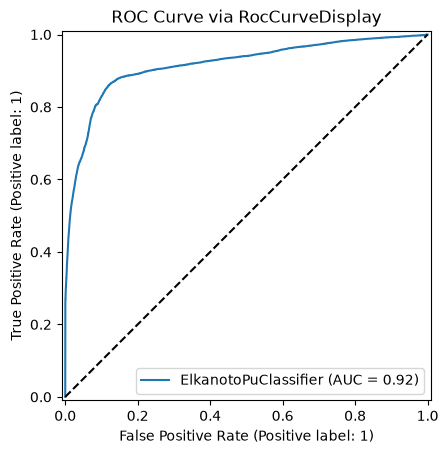

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


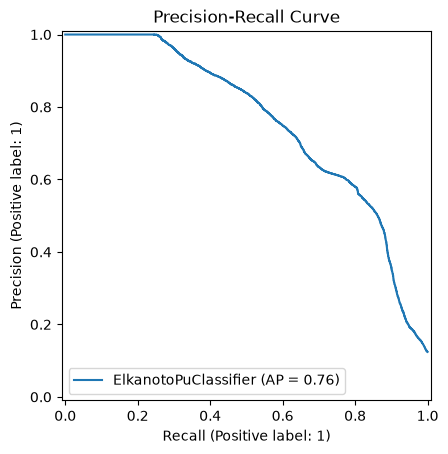

In [10]:

#=========== plotting
#======== ROC
RocCurveDisplay.from_estimator(pu_estimator, X_test_final, y_test_final)

plt.title("ROC Curve via RocCurveDisplay")
plt.plot([0, 1], [0,1], 'k--') 
plt.savefig("image/ROC_Curve.png")
#mlflow.log_artifact("image/ROC_Curve.png")
plt.show()    
plt.close()
# ======= PRC 
PrecisionRecallDisplay.from_estimator(pu_estimator, X_test_final, y_test_final)

plt.title("Precision-Recall Curve")
plt.savefig("image/PRC_Curve.png")
#mlflow.log_artifact("image/PRC_Curve.png")
plt.show()    
plt.close()

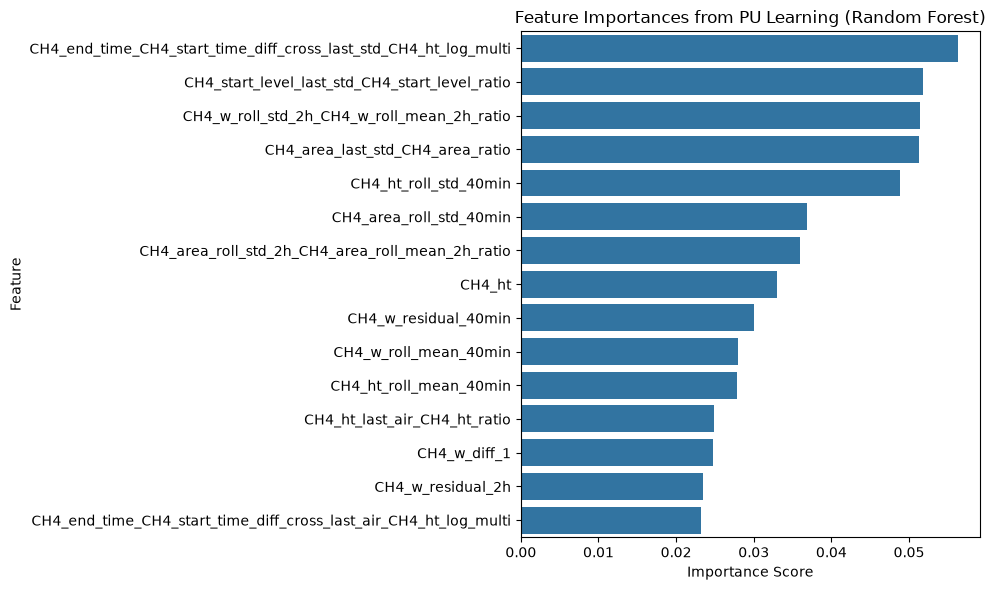

In [20]:
base_rf = pu_estimator.estimator

importances = base_rf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(15))
plt.title('Feature Importances from PU Learning (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [9]:
best_threshold = 0.85
y_prob = pu_estimator.predict_proba(X_test_final)[:,1]
y_prob = np.clip(y_prob, 0.0, 1.0)
y_proba_best = (y_prob >= best_threshold).astype(int)

analysis_df = pd.DataFrame({
    'original_index': X_test_final.index,
    'true_label': y_test.values,
    'predicted_label': y_proba_best,
    'predicted_prob': y_prob
}, index=X_test_final.index)

errors_df = analysis_df[analysis_df['true_label'] != analysis_df['predicted_label']].copy()

def error_type(row):
    if row['true_label'] == 1 and row['predicted_label'] == 0:
        return 'False Negative, actual 1; predicted 0, confirmed flag, but model missed'
    elif row['true_label'] == 0 and row['predicted_label'] == 1:
        return 'Potential Hidden Flag( actual 0; predicted 1; Unlabled, but high prob)'

errors_df['error_type'] = errors_df.apply(error_type, axis=1)

errors_df['severity'] = (errors_df['predicted_prob'] - best_threshold).abs()

errors_df = errors_df.join(X_test_final)

errors_df = errors_df.sort_values(by='severity', ascending=False)

print('==== ERROR SUMMARY===')
print(f'error per: {len(errors_df)/len(X_test_final):.2%}')

#errors_df.to_csv('error_analysis_with_index.csv', index=True)#=========
fp_flag_df = errors_df[errors_df['error_type'].str.contains('Potential Hidden Flag')].copy()

fp_flag_df.head(20)

/home/ellie/research_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


==== ERROR SUMMARY===
error per: 7.94%


,original_index,true_label,predicted_label,predicted_prob,error_type,severity,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_CH4_ht,last_air_CH4_ht,last_std_CH4_area,last_air_CH4_area,last_std_CH4_rt,last_air_CH4_rt,last_std_CH4_start_level,last_air_CH4_start_level,level_rt_ratio,rt_position,baseline_slope,level_area_ratio,CH4_area_diff_1,CH4_ht_diff_1,CH4_w_diff_1,CH4_area_lag_1,CH4_rt_lag_1,CH4_ht_lag_1,pflow_lag_1,CH4_w_lag_1,CH4_w_roll_std_40min,CH4_w_roll_std_2h,CH4_w_roll_std_6h,CH4_w_roll_std_24h,CH4_w_roll_std_2D,CH4_end_time_roll_std_40min,CH4_end_time_roll_std_2h,CH4_end_time_roll_std_6h,CH4_end_time_roll_std_24h,CH4_end_time_roll_std_2D,CH4_ht_roll_std_40min,CH4_ht_roll_std_2h,CH4_ht_roll_std_6h,CH4_ht_roll_std_24h,CH4_ht_roll_std_2D,CH4_area_roll_std_40min,CH4_area_roll_std_2h,CH4_area_roll_std_6h,CH4_area_roll_std_24h,CH4_area_roll_std_2D,CH4_rt_roll_mean_40min,CH4_rt_residual_40min,CH4_rt_roll_mean_2h,CH4_rt_residual_2h,CH4_rt_roll_mean_6h,CH4_rt_residual_6h,CH4_rt_roll_mean_24h,CH4_rt_residual_24h,CH4_rt_roll_mean_2D,CH4_rt_residual_2D,CH4_w_roll_mean_40min,CH4_w_residual_40min,CH4_w_roll_mean_2h,CH4_w_residual_2h,CH4_w_roll_mean_6h,CH4_w_residual_6h,CH4_w_roll_mean_24h,CH4_w_residual_24h,CH4_w_roll_mean_2D,CH4_w_residual_2D,CH4_ht_roll_mean_40min,CH4_ht_residual_40min,CH4_ht_roll_mean_2h,CH4_ht_residual_2h,CH4_ht_roll_mean_6h,CH4_ht_residual_6h,CH4_ht_roll_mean_24h,CH4_ht_residual_24h,CH4_ht_roll_mean_2D,CH4_ht_residual_2D,CH4_area_roll_mean_40min,CH4_area_residual_40min,CH4_area_roll_mean_2h,CH4_area_residual_2h,CH4_area_roll_mean_6h,CH4_area_residual_6h,CH4_area_roll_mean_24h,CH4_area_residual_24h,CH4_area_roll_mean_2D,CH4_area_residual_2D,CH4_end_time_CH4_start_time_diff_cross,last_std_CH4_ht_last_air_CH4_ht_diff_cross,CH4_ht_last_std_CH4_ht_diff_cross,CH4_ht_last_air_CH4_ht_diff_cross,last_std_CH4_ht_log,last_air_CH4_ht_log,CH4_w_CH4_ht_multi,CH4_end_time_CH4_start_time_diff_cross_last_std_CH4_ht_log_multi,CH4_end_time_CH4_start_time_diff_cross_last_air_CH4_ht_log_multi,CH4_area_CH4_w_CH4_ht_multi_ratio,CH4_ht_CH4_area_ratio,CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio,CH4_ht_last_air_CH4_ht_ratio,last_std_CH4_ht_last_air_CH4_ht_ratio,CH4_start_level_CH4_end_level_ratio,CH4_area_last_std_CH4_area_ratio,CH4_start_level_last_std_CH4_start_level_ratio,CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio,CH4_ht_roll_std_40min_CH4_ht_roll_mean_40min_ratio,CH4_area_roll_std_40min_CH4_area_roll_mean_40min_ratio,CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio,CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio,CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio,CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio,CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio,CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio,CH4_ht_diff_1_CH4_ht_lag_1_per_change,last_std_CH4_ht_last_air_CH4_ht_per_change,CH4_w_relative_per_2h,CH4_w_relative_per_7h,CH4_end_time_relative_per_2h,CH4_end_time_relative_per_7h,CH4_ht_relative_per_2h,CH4_ht_relative_per_7h,CH4_w_2h_zcore_res_gen,CH4_w_per_rank_7h,CH4_w_per_rank_7D,CH4_w_per_rank_30D,CH4_skew_per_rank_7h,CH4_skew_per_rank_7D,CH4_skew_per_rank_30D,CH4_ht_per_rank_7h,CH4_ht_per_rank_7D,CH4_ht_per_rank_30D
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-07-06 12:05:00,2025-07-06 12:05:00,0,1,1.0,Potential Hidden Flag( actual 0; predicted 1; ...,0.15,800.200012,40.0,96.000000,7.79,165991.0,1439762.0,1.07,82.800003,134.800003,28455.0,28635.0,1,0,163544.0,165960.0,1443623.0,1442543.0,96.000000,96.000000,28371.0,28199.0,0.541667,1.694480,23.106546,0.019889,-3861.0,2447.0,-0.13,1443623.0,96.000000,163544.0,808.799988,7.92,0.084853,0.050761,0.030705,0.021510,0.018146,0.141421,0.163299,0.155509,0.125469,0.111545,1708.369995,1284.904297,946.466309,854.504333,955.984436,763.675354,5864.546875,6656.481934,6186.773926,7806.000977,96.000000,

-----------------------------------

In [ ]:

#X_train_final = X_train_final[feature_ml]

pipe_rnd = Pipeline([
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])

param_grid = {
    'clf__n_estimators': [200],
    'clf__max_depth': [5, 8],
    'clf__min_samples_leaf':[15],
    'clf__random_state':[42],
    'clf__max_features':['sqrt'],
    'clf__n_jobs':[4],
    'clf__class_weight':['balanced']
}

/home/ellie/research_project/0722/feature_eng.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_roll_mean_{p}'] =mean_col #.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
/home/ellie/research_project/0722/feature_eng.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_roll_mean_{p}'] =mean_col #.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
/home/ellie/research_project/0722/feature_eng.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is 

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       ...
       'CH4_w_2h_zcore_res_gen', 'CH4_w_per_rank_7h', 'CH4_w_per_rank_7D',
       'CH4_w_per_rank_30D', 'CH4_skew_per_rank_7h', 'CH4_skew_per_rank_7D',
       'CH4_skew_per_rank_30D', 'CH4_ht_per_rank_7h', 'CH4_ht_per_rank_7D',
       'CH4_ht_per_rank_30D'],
      dtype='object', length=137)


In [14]:
X_train_final.columns.to_list()

['pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'level_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_ht_diff_1',
 'CH4_w_diff_1',
 'CH4_area_lag_1',
 'CH4_rt_lag_1',
 'CH4_ht_lag_1',
 'pflow_lag_1',
 'CH4_w_lag_1',
 'CH4_w_roll_std_40min',
 'CH4_w_roll_std_2h',
 'CH4_w_roll_std_6h',
 'CH4_w_roll_std_24h',
 'CH4_w_roll_std_2D',
 'CH4_end_time_roll_std_40min',
 'CH4_end_time_roll_std_2h',
 'CH4_end_time_roll_std_6h',
 'CH4_end_time_roll_std_24h',
 'CH4_end_time_roll_std_2D',
 'CH4_ht_roll_std_40min',
 'CH4_ht_roll_std_2h',
 'CH4_ht_roll_std_6h',
 'CH4_ht_roll_std_24h',
 'CH4_ht_roll_std_2D',
 'CH4_area_roll_std_40min',
 'CH4_area_roll_std_

/home/ellie/research_project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best hyparameter set 5-fold mean training AP: 0.72632
Best hyparameter set 5- fold mean validation set: 0.56946


/home/ellie/research_project/0722/feature_eng.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_roll_mean_{p}'] =mean_col #.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
/home/ellie/research_project/0722/feature_eng.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_roll_mean_{p}'] =mean_col #.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
/home/ellie/research_project/0722/feature_eng.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is 

====Evaluation report best threshold ===
Best threshold:0.6162
Best F1-score:0.6264; Best Precision:0.6489, Recall:0.6054
              precision    recall  f1-score   support

           0       0.94      0.95      0.95    136131
           1       0.65      0.61      0.63     19315

    accuracy                           0.91    155446
   macro avg       0.80      0.78      0.79    155446
weighted avg       0.91      0.91      0.91    155446



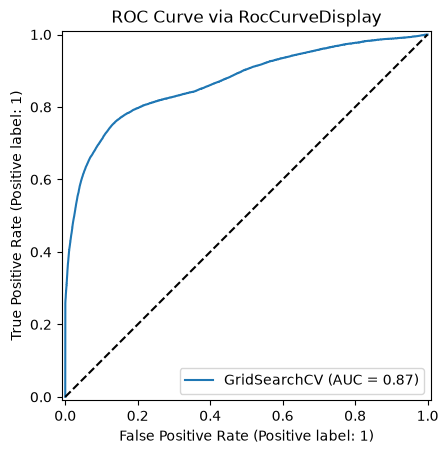

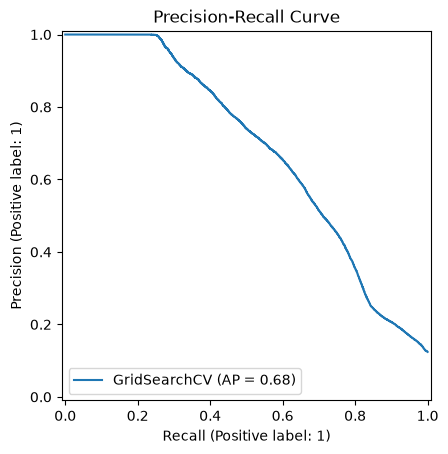

                                               Feature  Importance
113         CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio    0.053531
116         CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio    0.051880
114       CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio    0.035644
115   CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio    0.031975
110   CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio    0.031166
118   CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio    0.030568
64                                CH4_w_residual_40min    0.030292
66                                   CH4_w_residual_2h    0.025396
8                                         CH4_end_time    0.025196
101  CH4_end_time_CH4_start_time_diff_cross_last_ai...    0.025063
68                                   CH4_w_residual_6h    0.024362
100  CH4_end_time_CH4_start_time_diff_cross_last_st...    0.023876
93              CH4_end_time_CH4_start_time_diff_cross    0.022610
109     CH4_start_level_last_std_CH4_start_level_ratio    0.02

In [15]:
#with mlflow.start_run(run_name="RF_GridSearch_0720_v1") as parent_run:
dataset_metadat={
    'feature_cols': feature_cols,
    'feature_config': feature_config,
    #'feature_ml':feature_ml
}
#mlflow.log_dict(dataset_metadat, 'feature_config.json')

grid = GridSearchCV(estimator=pipe_rnd, param_grid = param_grid, cv=tscv,  scoring='average_precision', n_jobs=4, return_train_score=True)
grid.fit(X_train_final, y_train_final)

# print best model score
cv_results = pd.DataFrame(grid.cv_results_)
best_index = grid.best_index_
mean_train = cv_results.loc[best_index, 'mean_train_score']
mean_test = cv_results.loc[best_index, 'mean_test_score']

print(f"Best hyparameter set 5-fold mean training AP: {mean_train:.5f}")
print(f"Best hyparameter set 5- fold mean validation set: {mean_test:.5f}")

    
X_test_final = tsfe.fit_transform(X_test)
y_test_final = y_test.copy()
#X_test_final = X_test_final[feature_ml]
#=========== Evaluation Report
y_prob = grid.predict_proba(X_test_final)[:, 1]
best_threshold, best_f1, best_prec, best_rec = get_best_threshold(y_test_final, y_prob)
y_proba_best = (y_prob >= best_threshold).astype(int)

print("====Evaluation report best threshold ===")
print(f'Best threshold:{best_threshold:.4f}')
print(f'Best F1-score:{best_f1:.4f}; Best Precision:{best_prec:.4f}, Recall:{best_rec:.4f}')
print(classification_report(y_test_final, y_proba_best))
#=========== plotting
#======== ROC
RocCurveDisplay.from_estimator(grid, X_test_final, y_test_final)

plt.title("ROC Curve via RocCurveDisplay")
plt.plot([0, 1], [0,1], 'k--') 
plt.savefig("image/ROC_Curve.png")
#mlflow.log_artifact("image/ROC_Curve.png")
plt.show()    
plt.close()
# ======= PRC 
PrecisionRecallDisplay.from_estimator(grid, X_test_final, y_test_final)

plt.title("Precision-Recall Curve")
plt.savefig("image/PRC_Curve.png")
#mlflow.log_artifact("image/PRC_Curve.png")
plt.show()    
plt.close()
#==========feature importance
best_clf = grid.best_estimator_.named_steps['clf']

feature_names = X_train_final.columns
importances = best_clf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_imp_df.head(20))
print(feature_imp_df['Feature'].head(25).tolist())
#========= SHAP
#best_pipeline = grid.best_estimator_
#final_rf_model = best_pipeline.named_steps['clf']


#explainer = shap.TreeExplainer(final_rf_model)
#shap_values = explainer(X_test_final)

#shap.plots.beeswarm(shap_values[:, :, 1], max_display=72)
#plt.savefig("image/shap_summary.png")
#mlflow.log_artifact("image/shap_summary.png")
#plt.show()    
#plt.close()


print("All Done!")




----------------------------------

rf_all_feature
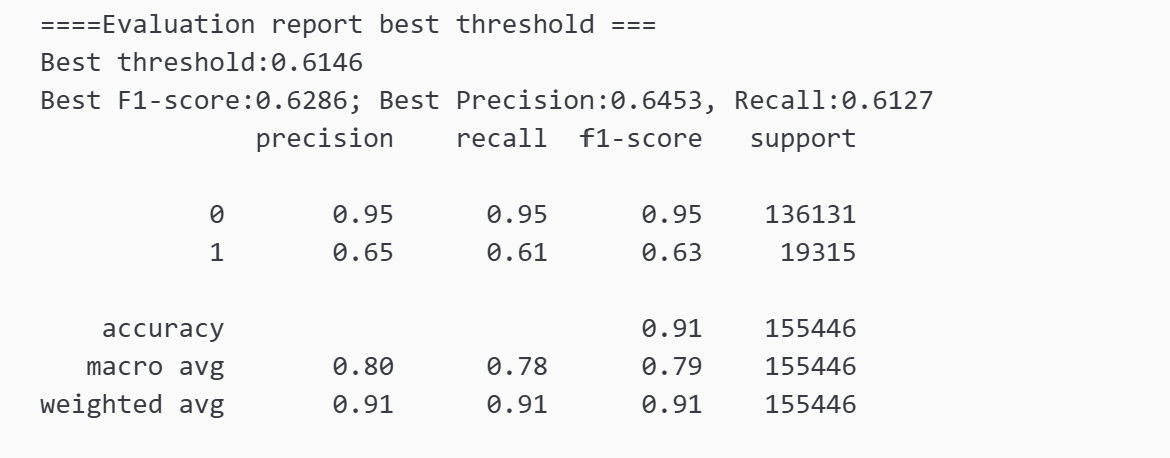
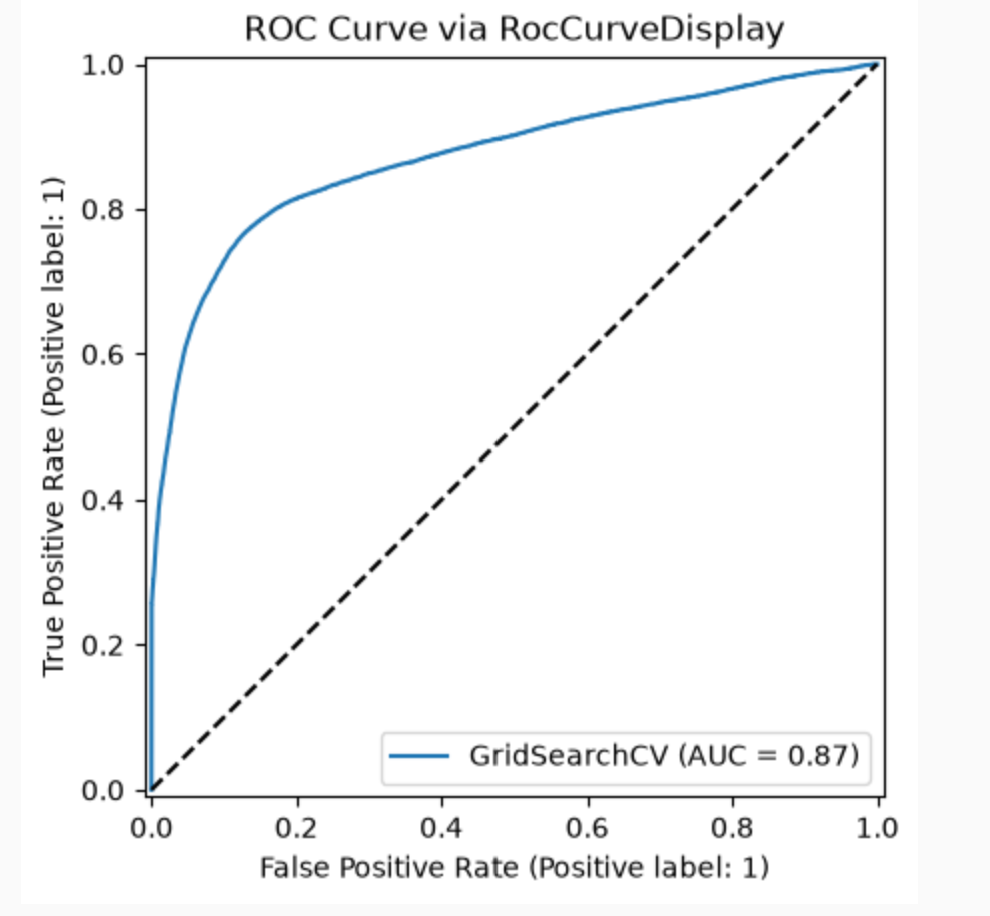
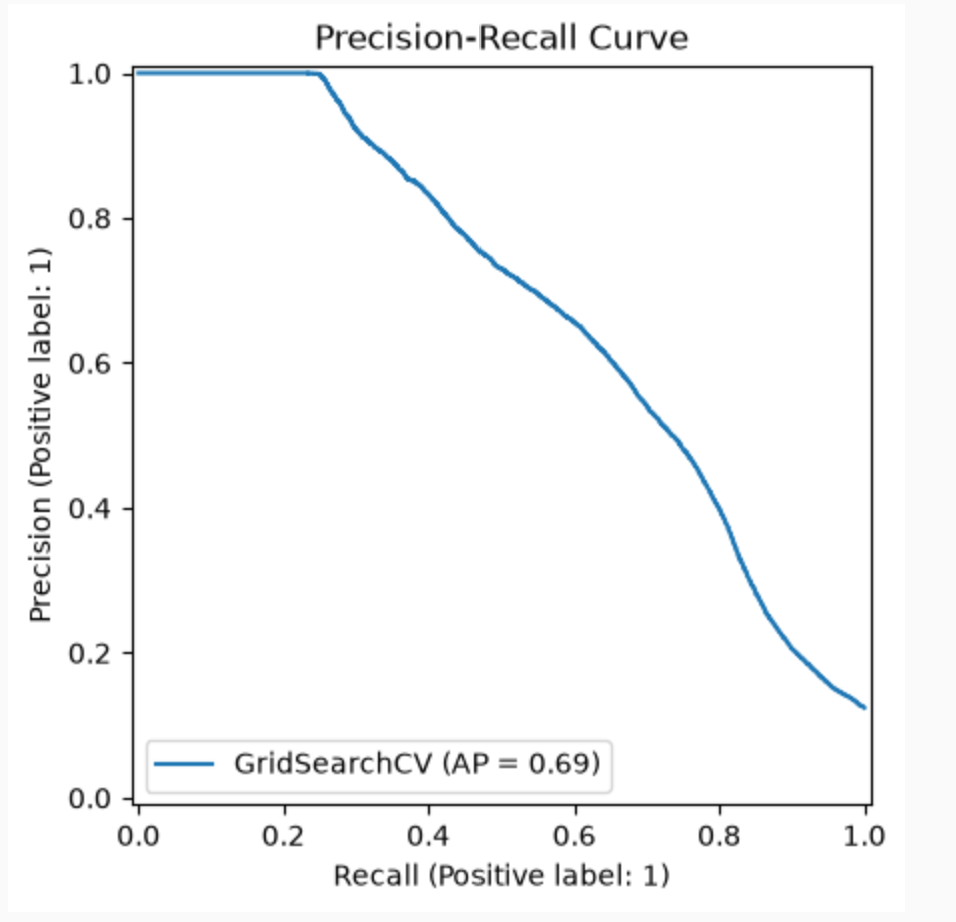

rf_importanttop_20
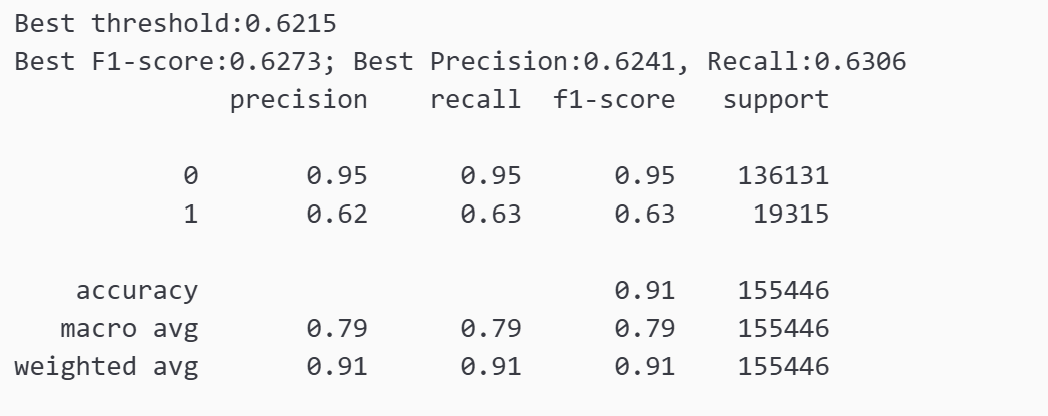
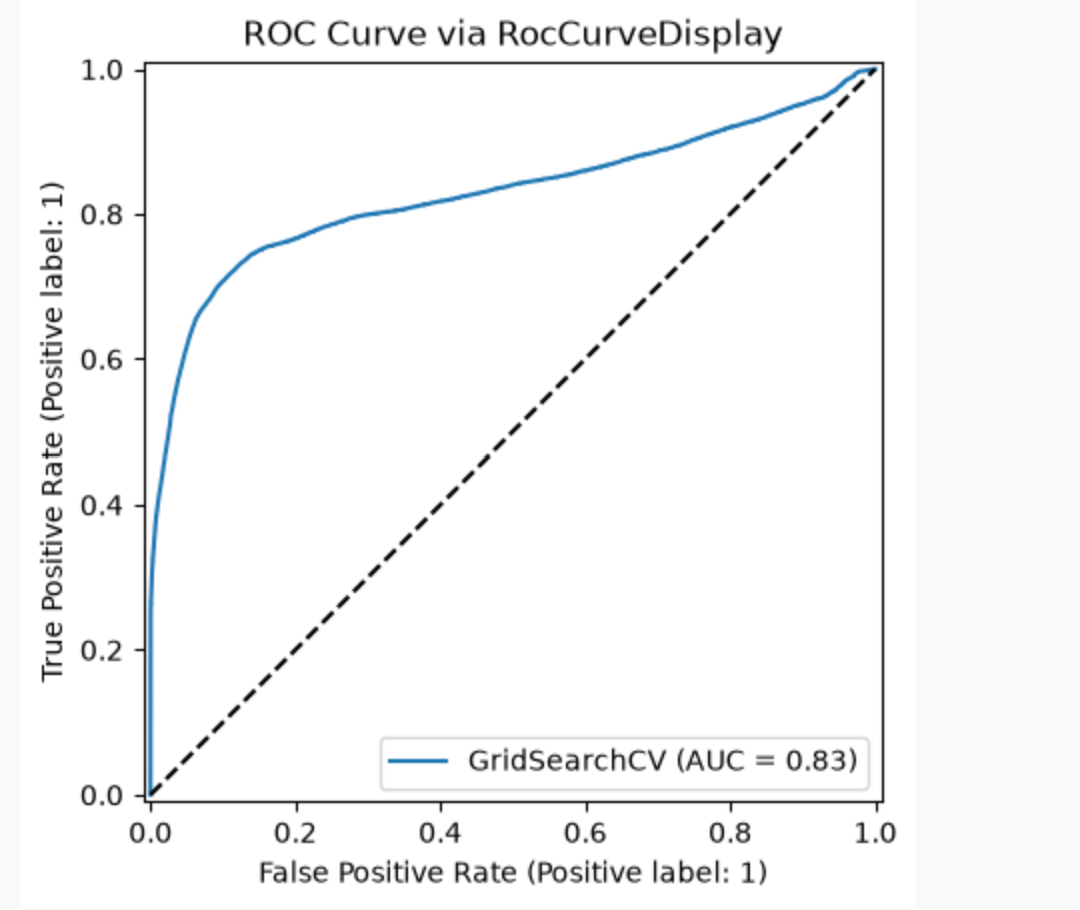
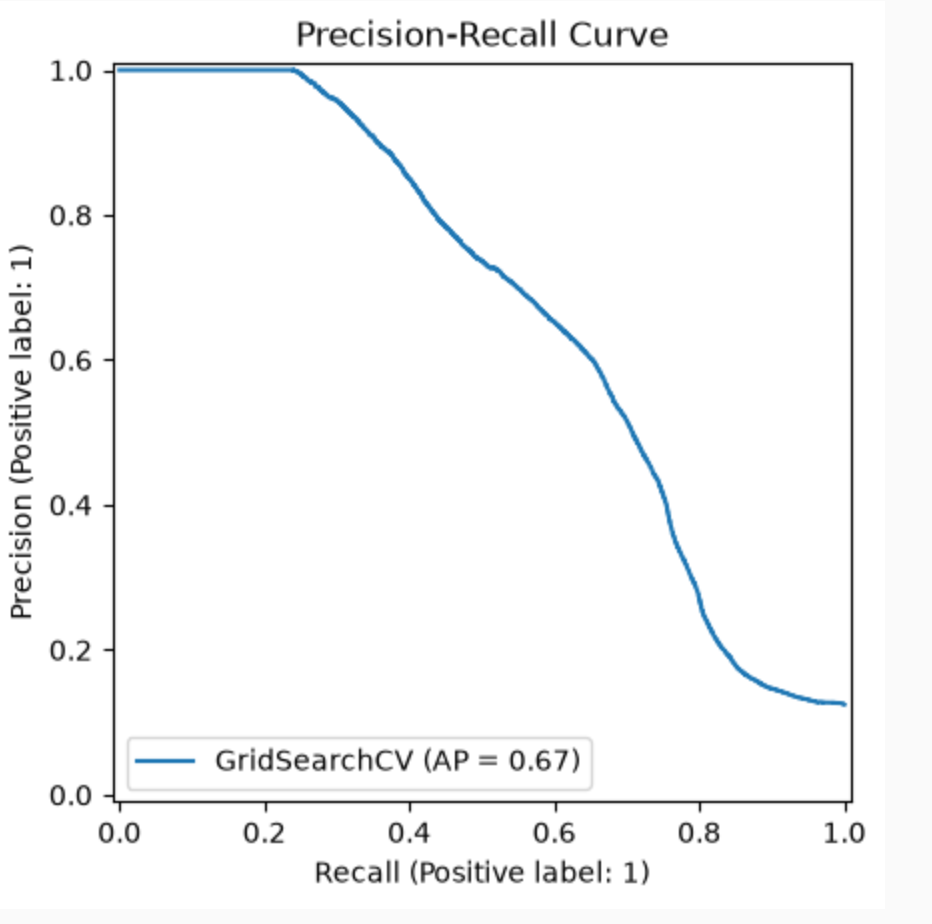

In [35]:
len(top20_corr)
len(top20_rf)

25

In [36]:
top20_corr = ['CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio', 'CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio', 'CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio', 'CH4_end_time_CH4_start_time_diff_cross_last_std_CH4_ht_log_multi', 'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio', 'CH4_end_time_CH4_start_time_diff_cross_last_air_CH4_ht_log_multi', 'CH4_end_time_CH4_start_time_diff_cross', 'CH4_start_level_last_std_CH4_start_level_ratio', 'last_air_CH4_ht_log', 'CH4_end_time', 'last_std_CH4_ht_log', 'CH4_rt_roll_mean_2h', 'CH4_skew', 'CH4_area_roll_std_40min_CH4_area_roll_mean_40min_ratio', 'CH4_ht_roll_std_40min_CH4_ht_roll_mean_40min_ratio', 'CH4_w', 'CH4_rt_roll_mean_40min', 'CH4_rt', 'last_air_CH4_rt', 'last_std_CH4_rt']
top20_rf =['CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio', 'CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio', 'CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio', 'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio', 'CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio', 'CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio', 'CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio', 'CH4_w_residual_6h', 'CH4_end_time_CH4_start_time_diff_cross_last_air_CH4_ht_log_multi', 'CH4_w_residual_40min', 'CH4_w_residual_2h', 'CH4_end_time_CH4_start_time_diff_cross', 'CH4_w_diff_1', 'CH4_end_time_CH4_start_time_diff_cross_last_std_CH4_ht_log_multi', 'CH4_rt_roll_mean_2h', 'CH4_w_roll_std_2h', 'CH4_w_roll_mean_2h', 'CH4_start_level_last_std_CH4_start_level_ratio', 'CH4_end_time', 'rt_position'] #'CH4_area_last_std_CH4_area_ratio', 'CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio', 'CH4_area_roll_mean_2h', 'CH4_w_residual_24h', 'CH4_area_roll_mean_40min']

df_compare = pd.DataFrame({
    'Corr_rank':range(1,21),
    'Corr_Feature':top20_corr,
    'RF_Rank':range(1,21),
    'RF_Feature':top20_rf
})

df_compare['In_RF_TOP20'] = df_compare['Corr_Feature'].isin(top20_rf)
df_compare


,Corr_rank,Corr_Feature,RF_Rank,RF_Feature,In_RF_TOP20
0,1,CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio,1,CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio,True
1,2,CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio,2,CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio,True
2,3,CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio,3,CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio,True
3,4,CH4_end_time_CH4_start_time_diff_cross_last_st...,4,CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio,True
4,5,CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio,5,CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio,True
5,6,CH4_end_time_CH4_start_time_diff_cross_last_ai...,6,CH4_w_roll_std_40min_CH4_w_roll_mean_40min_ratio,True
6,7,CH4_end_time_CH4_start_time_diff_cross,7,CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio,True
7,8,CH4_start_level_last_std_CH4_start_level_ratio,8,CH4_w_residual_6h,True
8,9,last_air_CH4_ht_log,9,CH4_end_time_CH4_start_time_diff_cross_last_ai...,False
9,10,CH4_end_time,10,CH4_w_residual_40min,True


In [27]:
joblib.dump(grid.best_estimator_, 'iscnan_0720.pkl')

['iscnan_0720.pkl']

In [ ]:
best_threshold
y_prob = grid.best_estimator_.predict_proba(X_test_final)[:, 1]
y_proba_best = (y_prob >= best_threshold).astype(int)

analysis_df = pd.DataFrame({
    'original_index': X_test_final.index,
    'true_label': y_test.values,
    'predicted_label': y_proba_best,
    'predicted_prob': y_prob
}, index=X_test_final.index)

errors_df = analysis_df[analysis_df['true_label'] != analysis_df['predicted_label']].copy()

def error_type(row):
    if row['true_label'] == 1 and row['predicted_label'] == 0:
        return 'False Negative, actual 1; predicted 0'
    elif row['true_label'] == 0 and row['predicted_label'] == 1:
        return 'False Positive, actual 0; predicted 1'

errors_df['error_type'] = errors_df.apply(error_type, axis=1)

errors_df['severity'] = (errors_df['predicted_prob'] - best_threshold).abs()

errors_df = errors_df.join(X_test_final)

errors_df = errors_df.sort_values(by='severity', ascending=False)

print('==== ERROR SUMMARY===')
print(f'error per: {len(errors_df)/len(X_test_final):.2%}')

#errors_df.to_csv('error_analysis_with_index.csv', index=True)
errors_df.head(20)

==== ERROR SUMMARY===
error per: 8.48%


,original_index,true_label,predicted_label,predicted_prob,error_type,severity,CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio,CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio,CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio,CH4_end_time_CH4_start_time_diff_cross_last_std_ht_log_multi,CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio,CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio,CH4_w_residual_6h,CH4_w_diff_1,CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio,CH4_w_residual_2h,level_area_ratio,CH4_area_last_std_area_ratio,CH4_end_time_CH4_start_time_diff_cross,CH4_ht_roll_mean_2h,CH4_end_time,CH4_w_roll_std_2h,CH4_w_diff_2,CH4_w_roll_mean_2h,CH4_rt_roll_mean_2h,CH4_end_time_CH4_start_time_diff_cross_last_air_ht_log_multi,CH4_w_roll_std_6h,CH4_start_level_last_std_start_level_ratio,CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio,rt_position,level_rt_ratio
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2019-09-14 22:39:00,2019-09-14 22:39:00,1,0,0.193479,"False Negative, actual 1; predicted 0",0.475615,0.000685,0.001384,0.004150,633.941223,0.002232,0.001528,0.066357,0.00,0.003448,0.044228,0.023316,0.995907,53.200001,149396.171875,141.199997,0.005164,0.00,7.536667,102.199997,633.890686,0.010432,0.998838,0.141729,1.883289,0.520548
2019-09-14 22:19:00,2019-09-14 22:19:00,1,0,0.193479,"False Negative, actual 1; predicted 0",0.475615,0.000727,0.001382,0.004157,633.718262,0.001824,0.001312,0.073735,0.00,0.003481,0.066357,0.023250,1.006170,53.200001,149368.000000,141.199997,0.005477,0.01,7.535000,102.199997,633.890686,0.010416,1.002663,0.141729,1.883289,0.520548
2019-09-13 17:59:00,2019-09-13 17:59:00,1,0,0.194793,"False Negative, actual 1; predicted 0",0.474301,0.000835,0.002132,0.006107,636.831848,0.006442,0.005850,-0.205068,0.01,0.005440,0.000000,0.023167,1.010979,53.400002,152043.328125,141.199997,0.006325,0.00,7.570000,102.199997,637.355896,0.016169,0.999446,0.141760,1.902246,0.522505
2019-09-13 18:39:00,2019-09-13 18:39:00,1,0,0.197088,"False Negative, actual 1; predicted 0",0.472006,0.001822,0.002515,0.006041,637.190796,0.005379,0.004792,-0.146563,0.03,0.005225,0.066094,0.023080,1.010164,53.400002,152103.171875,141.199997,0.013784,0.00,7.565000,102.166664,637.396484,0.019063,0.999479,0.141760,1.902246,0.522505
2019-09-13 11:59:00,2019-09-13 11:59:00,1,0,0.200743,"False Negative, actual 1; predicted 0",0.468351,0.003083,0.002502,0.013677,639.174072,0.006801,0.005508,0.161290,0.03,0.013233,0.087912,0.023071,1.017566,53.599998,152341.671875,141.399994,0.023381,0.04,7.583333,102.199997,639.712036,0.018960,1.000130,0.141604,1.897233,0.524462
2019-09-13 10:59:00,2019-09-13 10:59:00,1,0,0.201419,"False Negative, actual 1; predicted 0",0.467675,0.001102,0.002406,0.014642,639.559326,0.005704,0.005402,0.469415,0.02,0.013811,0.197498,0.023136,1.001774,53.599998,152567.328125,141.399994,0.008367,0.01,7.595000,102.199997,639.984436,0.018222,1.000554,0.141978,1.892247,0.524462
2019-09-13 12:19:00,2019-09-13 12:19:00,1,0,0.201872,"False Negative, actual 1; predicted 0",0.467222,0.003083,0.002457,0.013668,636.789124,0.006734,0.005507,0.271201,0.01,0.013243,0.219780,0.023286,1.008567,53.400002,152341.500000,141.199997,0.023381,0.04,7.583333,102.199997,637.545227,0.018621,0.998471,0.142322,1.894737,0.522505
2019-09-13 17:39:00,2019-09-13 17:39:00,1,0,0.207200,"False Negative, actual 1; predicted 0",0.461894,0.000539,0.002132,0.006258,639.300293,0.005896,0.005565,-0.336898,-0.01,0.005508,-0.154083,0.023436,0.997574,53.599998,152079.828125,141.399994,0.004082,-0.01,7.571667,102.199997,639.742981,0.016169,1.000522,0.141045,1.904762,0.524462
2019-09-13 18:19:00,2019-09-13 18:19:00,1,0,0.211922,"False Negative, actual 1; predicted 0",0.457172,0.000835,0.002179,0.005931,636.831848,0.005649,0.005231,-0.585995,-0.03,0.005304,-0.396301,0.023314,1.004207,53.400002,151970.828125,141.199997,0.006325,-0.02,7.570000,102.199997,637.396484,0.016529,0.999772,0.141199,1.883289,0.523529


In [21]:
best_clf = grid.best_estimator_.named_steps['clf']

feature_names = X_train_final.columns
importances = best_clf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_imp_df['Feature'].head(25).tolist()
#feature_imp_df.head(20)


['CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio',
 'CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio',
 'CH4_w_diff_1',
 'CH4_area_roll_std_6h_CH4_ht_roll_mean_6h_ratio',
 'CH4_end_time_CH4_start_time_diff_cross_last_std_ht_log_multi',
 'CH4_w_residual_6h',
 'CH4_area_roll_std_2h_CH4_w_roll_mean_2h_ratio',
 'CH4_w_residual_2h',
 'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio',
 'CH4_area_last_std_area_ratio',
 'CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio',
 'level_area_ratio',
 'CH4_w_roll_std_2h',
 'CH4_w_diff_2',
 'CH4_w_roll_mean_2h',
 'CH4_ht_last_std_ht_diff_cross',
 'CH4_end_time_CH4_start_time_diff_cross_last_air_ht_log_multi',
 'CH4_end_time',
 'CH4_w_roll_std_6h',
 'CH4_start_level_last_std_start_level_ratio',
 'CH4_ht_diff_2',
 'CH4_rt_roll_mean_2h',
 'CH4_end_time_CH4_start_time_diff_cross',
 'CH4_ht_roll_mean_2h',
 'CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio']

In [13]:
shap_values_pos = shap_values[:,:, 1]
mean_shap_values = np.abs(shap_values_pos.values).mean(axis=0)

df_shap = pd.DataFrame({
    'fn':shap_values_pos .feature_names,
    'shap_imp':mean_shap_values
}).sort_values(by='shap_imp', ascending=False)

top_20 = df_shap['fn'].head(20).tolist()
print(top_20)

['CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio', 'CH4_ht_roll_mean_2h', 'CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio', 'CH4_w_roll_std_7h_CH4_w_roll_mean_7h_ratio', 'CH4_area_CH4_w_CH4_ht_multi_ratio', 'CH4_ht_last_std_ht_diff_cross', 'CH4_w_diff_1', 'CH4_w_residual_7h', 'CH4_end_time_CH4_start_time_diff_cross', 'CH4_skew', 'CH4_ht_roll_mean_7h', 'CH4_end_time_CH4_start_time_diff_cross_last_std_ht_log_multi', 'CH4_start_level', 'CH4_w_residual_2h_log', 'CH4_w_roll_std_2h', 'last_air_ht', 'CH4_rt', 'CH4_w_residual_2h', 'CH4_area_diff_1', 'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio']


In [ ]:
feature_ml = ['CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio', 
              'CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio', 
              'CH4_area_roll_std_6h_CH4_area_roll_mean_6h_ratio', 
              'CH4_end_time_CH4_start_time_diff_cross_last_std_ht_log_multi', 
              'CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio', 
              'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio', 
              'CH4_w_residual_6h', 
              'CH4_w_diff_1',
                'CH4_ht_roll_std_6h_CH4_ht_roll_mean_6h_ratio', 
               'CH4_w_residual_2h', 
               'level_area_ratio',
                'CH4_area_last_std_area_ratio', 
                'CH4_end_time_CH4_start_time_diff_cross',
                'CH4_ht_roll_mean_2h', 
                'CH4_end_time', 
                'CH4_w_roll_std_2h', 
                'CH4_w_diff_2',
                'CH4_w_roll_mean_2h', 
                'CH4_rt_roll_mean_2h', 
                'CH4_end_time_CH4_start_time_diff_cross_last_air_ht_log_multi',
                'CH4_w_roll_std_6h', 
                'CH4_start_level_last_std_start_level_ratio', 
                'CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio', 
                'rt_position', 'level_rt_ratio']

In [42]:
X_train_final.columns

Index(['pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'last_std_ht', 'last_air_ht', 'CH4_ht_diff_1', 'CH4_ht_diff_2',
       'CH4_area_lag_1', 'CH4_area_lag_2', 'CH4_rt_lag_1', 'CH4_rt_lag_2',
       'CH4_ht_lag_1', 'CH4_ht_lag_2', 'CH4_skew_lag_1', 'CH4_skew_lag_2',
       'CH4_w_roll_std_2h', 'CH4_w_roll_std_7h', 'CH4_w_roll_std_12h',
       'CH4_w_roll_std_19h', 'CH4_w_roll_std_1D', 'CH4_w_roll_std_2D',
       'CH4_end_time_roll_std_2h', 'CH4_end_time_roll_std_7h',
       'CH4_end_time_roll_std_12h', 'CH4_end_time_roll_std_19h',
       'CH4_end_time_roll_std_1D', 'CH4_end_time_roll_std_2D',
       'CH4_w_roll_mean_2h', 'CH4_w_residual_2h', 'CH4_w_roll_mean_7h',
       'CH4_w_residual_7h', 'CH4_w_roll_mean_12h', 'CH4_w_residual_12h',
       'CH4_w_roll_mean_19h', 'CH4_w_residual_19h', 'CH4_w_roll_mean_1D',
       'CH4_w_residual_1D', 'CH4_w_roll_mean_2D', 'CH4_w_residual_2D',
       'CH

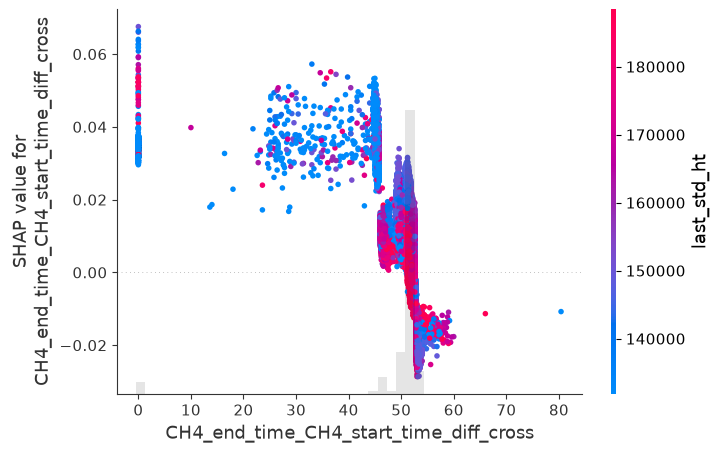

In [33]:
shap.plots.scatter(
    shap_values[:, 'CH4_end_time_CH4_start_time_diff_cross', 1],
    color=shap_values[:, :, 1]
)

In [10]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](78,)","['pflow','CH4_rt','CH4_w',...,'CH4_ht_diff_1_CH4_ht_lag_1_per_change', 'CH4_w_7D_zcore_res_gen','CH4_w_residual_2h_log']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,78
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2


In [67]:
y_prob = grid.best_estimator_.predict_proba(X_test_final)[:, 1]
best_threshold, best_f1, best_prec, best_rec = get_best_threshold(y_test_final, y_prob)
y_proba_best = (y_prob >= best_threshold).astype(int)

print("====Evaluation report best threshold ===")
print(f'Best threshold:{best_threshold:.4f}')
print(f'Best F1-score:{best_f1:.4f}; Best Precision:{best_prec:.4f}, Recall:{best_rec:.4f}')
print(classification_report(y_test_final, y_proba_best))

====Evaluation report best threshold ===
Best threshold:0.5463
Best F1-score:0.6229; Best Precision:0.5106, Recall:0.7983
              precision    recall  f1-score   support

           0       0.97      0.89      0.93    136131
           1       0.51      0.80      0.62     19315

    accuracy                           0.88    155446
   macro avg       0.74      0.84      0.78    155446
weighted avg       0.91      0.88      0.89    155446

